# 08 — IBIS2026: DEと低ランク近似の対応比較

**本番未実行。結果は実行後に生成します。** 0721の探索結果を、同一rank・共通の元モデルから検証する実験ノートです。既存06/07は変更しません。

- 実験1：全blockの同一モジュールを処理。共通のモデル全体削減予算＋**preDE MP rankをDEあり／なしで共有**。
- 実験2：未圧縮状態から1行列のみを処理。浅・中・深層を事前固定＋0721の3例。任意で全行列の短縮評価。
- 実験3：共通のKS順序で累積LRA。各条件のMP rankを使い、PPL–削減率を比較。
- 主指標：トークン加重NLL、PPL、対応改善量 `G=NLL_OffDE−NLL_DE`（正がDE優位）。

実行手順：①環境とDrive設定 → ②入力・モデル構成から計画表作成 → ③計画表を確認 → ④`RUN_EXPERIMENTS=True`で本番セル → ⑤分析。結果分析だけの再実行はFalseのままで可。
ColabではまずL4級で推論を試し、メモリ不足時は評価batchを1にしてください。A100を前提にしません。LoRA学習は含みません。

### Gemma読み込み修正（2026-10-01）
旧Gemma結果は重みロード不全のため分析から除外します。`gemma_loader_v2/` にbaseline・122条件・近似キャッシュを新規保存します。Llamaは従来の保存済み結果をそのまま読み込みます。全セルを上から再実行して関数定義を更新してください。`POST_RANK_SOURCE` とTAGは既存設定を維持します。
重みのmissing/unexpected/mismatchedがあれば停止します。未圧縮baseline PPLが1000超でもLRA開始前に停止します。この閾値は正常性の十分条件ではありません。


## 1. 環境
VS CodeからColabに接続する場合も、HF認証は環境変数または下の入力欄を使用します。Colab secretsを呼びません。最初にRMT_utilsが必要です。ローカルでは既存checkout、Colabでは未存在の場合だけGitHubから取得します。インストール後にカーネル再起動が求められた場合は再起動してください。

In [1]:
from pathlib import Path
import os, sys, subprocess, getpass
INSTALL_DEPENDENCIES = False
CLONE_IF_MISSING = True
REPO = Path('/content/RMT_utils') if Path('/content').exists() else Path.home() / 'GitHub/RMT_utils'
if not (REPO / 'funcs1.py').exists():
    if not CLONE_IF_MISSING:
        raise FileNotFoundError(f'RMT_utils not found: {REPO}')
    subprocess.run(['git', 'clone', 'https://github.com/ryy1210/RMT_utils', str(REPO)], check=True)
if INSTALL_DEPENDENCIES:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(REPO/'requirements-notebooks.txt')], check=True)
sys.path.insert(0, str(REPO))
# 必要なときだけ入力。キーをセル出力・設定ファイルに保存しない。
if not os.environ.get('HF_TOKEN'):
    token = getpass.getpass('HF_TOKEN (cached loginなら空欄): ')
    if token: os.environ['HF_TOKEN'] = token
print('Repository:', REPO)

Repository: /content/RMT_utils


## 2. 設定
実験1の予算は「モデル全体のパラメータに対する割合」。言語モデルのみのパラメータ数を分母とし、Gemmaのvision towerは含めません。共通予算が実現不能なら停止するため、勝手に小さく丸めません。
実験2はpreDE MP rank固定で、各モデルの最初・中央・最後のblockを使います。全行列探索は既定OFFです。
実験3の既定は0721と同じ `KS_postDE_1_saved` 降順・postDE BEMA rank。分散1版は `POST_RANK_SOURCE='fixed1'` で別TAGにします。今回の固定rank条件はこの設定に影響されません。

rank=0は元のMP規則の一部として許可し計画表に明示します。因子化が密行列より大きい場合もrankを改変せず、密行列で保持した場合の削減量0を記録します。

In [2]:
import json, hashlib, math, gc, platform, re, time, importlib.metadata
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from funcs1 import apply_lra_1

MOUNT_DRIVE = True  # Colabで未マウントならTrue。VS CodeのDrive接続済みならFalse
if MOUNT_DRIVE and Path('/content').exists():
    from google.colab import drive
    drive.mount('/content/drive')
LOCAL_DRIVE = Path.home()/'Library/CloudStorage/GoogleDrive-ryoya.zushi1210@gmail.com/マイドライブ/TUS/hashiguchi/data'
DATA_ROOT = Path('/content/drive/MyDrive/TUS/hashiguchi/data') if Path('/content').exists() else LOCAL_DRIVE
SOURCE_TAG = 'bulk-ks-20260925-v1-full'
EXPERIMENT_TAG = 'ibis2026-de-controlled-v1'
OUTPUT = DATA_ROOT/'ibis2026_de_lra'/EXPERIMENT_TAG
MODELS = {'llama':'meta-llama/Llama-3.2-3B', 'gemma':'google/gemma-3-4b-pt'}
MODEL_REVISIONS = {k:'main' for k in MODELS}  # 初回計画時にcommitへ解決して固定
MODULES = ['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj']
MODEL_BUDGETS = [0.0025, 0.005, 0.01]
RUN_EXPERIMENTS = True
ENABLE_ALL_MATRIX_SCREEN = False
POST_RANK_SOURCE = 'fixed1'  # 'bema' reproduces 0721; 'fixed1' uses n_signal_DE_1
ORDER_COLUMN = 'KS_postDE_1_saved'
MAX_CUMULATIVE = 100
CUMULATIVE_STEPS = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
SEQ_LEN = 1024
BATCH_SIZE = 1
SCREEN_BLOCKS = 16
BOOTSTRAP_REPEATS = 2000
SEED = 42
PUBLISH_WANDB = True
WANDB_ENTITY = 'ryoya-zushi1210-tokyo-university-of-science'
WANDB_PROJECT = 'IBIS2026-DE-LRA'
AUTO_DISCONNECT = False
# PPLは両モデルで直接比較せず、同じtokenizerのbaselineとの差を比較する。
plt.rcParams.update({'figure.figsize':(9,4), 'font.size':11, 'axes.spines.top':False, 'axes.spines.right':False})

def sha(path): return hashlib.sha256(Path(path).read_bytes()).hexdigest()
def write_json(path, data):
    path=Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    temp=path.with_suffix(path.suffix+'.tmp')
    temp.write_text(json.dumps(data, ensure_ascii=False, indent=2, allow_nan=False))
    temp.replace(path)
def write_csv(path, frame):
    path=Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    temp=path.with_suffix('.tmp.csv'); frame.to_csv(temp,index=False); temp.replace(path)
def safe_exp(x): return math.exp(x) if x < 709 else float('inf')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. 入力確認とモデルサイズ
モデルの構成だけを読み、meta device上で形状とパラメータ数を取得します。このセルではモデル重みをダウンロードしません。保存rankと再計算rankの一致・全7モジュールの網羅・行列形状を検証します。

In [3]:
def load_metadata(key):
    path=DATA_ROOT/'bulk_ks'/key/SOURCE_TAG/'bulk_ks.csv'
    df=pd.read_csv(path)
    required=['name','p','n','module_type','block_index','s_hat_saved_preDE','s_hat_saved_postDE','n_signal_DE_1',ORDER_COLUMN]
    if not set(required)<=set(df): raise ValueError(f'Missing columns: {set(required)-set(df)}')
    if df.name.duplicated().any(): raise ValueError('Duplicate matrix names')
    if set(df.module_type)!=set(MODULES): raise ValueError('Module coverage mismatch')
    for col in ['rank_matches_saved_preDE','rank_matches_saved_postDE']:
        if not df[col].astype(str).str.lower().eq('true').all(): raise ValueError(f'{col}: mismatch')
    for col in ['s_hat_saved_preDE','s_hat_saved_postDE','n_signal_DE_1']:
        x=pd.to_numeric(df[col],errors='raise')
        if not (np.isfinite(x)&(x==np.floor(x))&(x>=0)&(x<=df.p)).all(): raise ValueError(f'Invalid rank: {col}')
    if not np.isfinite(df[ORDER_COLUMN]).all(): raise ValueError('Invalid order metric')
    config=AutoConfig.from_pretrained(MODELS[key],revision=MODEL_REVISIONS[key],token=os.environ.get('HF_TOKEN'))
    revision=getattr(config,'_commit_hash',None)
    if not revision: raise ValueError('Could not pin model revision')
    # Gemma3 multimodal configから言語モデルだけを作る。
    text_config=getattr(config,'text_config',config)
    with torch.device('meta'):
        shell=AutoModelForCausalLM.from_config(text_config)
        shell.tie_weights()
    total=sum(p.numel() for p in shell.parameters())
    modules=dict(shell.named_modules())
    for row in df.itertuples():
        matches=[name for name,mod in modules.items() if isinstance(mod,torch.nn.Linear) and (name==row.name or name.endswith('.'+row.name))]
        if len(matches)!=1: raise ValueError(f'Cannot resolve {row.name}: {matches}')
        m,n=modules[matches[0]].weight.shape
        if sorted([m,n])!=[int(row.p),int(row.n)]: raise ValueError(f'Shape mismatch {row.name}')
    del shell
    return df.sort_values(['block_index','module_type']).reset_index(drop=True), int(total), revision, sha(path)

METRICS={}; TOTAL={}; REVISIONS={}; SOURCE_HASH={}
for key in MODELS:
    METRICS[key],TOTAL[key],REVISIONS[key],SOURCE_HASH[key]=load_metadata(key)
    print(key, 'matrices:',len(METRICS[key]), 'language parameters:',TOTAL[key], 'revision:',REVISIONS[key])

llama matrices: 196 language parameters: 3212749824 revision: 13afe5124825b4f3751f836b40dafda64c1ed062
gemma matrices: 238 language parameters: 3880263168 revision: cc012e0a6d0787b4adcc0fa2c4da74402494554d


## 4. 計画を固定する
共通予算は同じモジュール内でほぼ同じ相対削減率になるようrankを割り当て、整数丸め分を記録します。同一予算のDEペアには同じrank表を渡します。
単一行列実験では変更後に重みを厳密に復元します。0721代表例は確認用3深度と区別します。実験3は共通KS降順の先頭集合を累積し、設定したcheckpointで評価します。

In [4]:
def cost(row,r): return min(int(row.p)*int(row.n),int(r)*(int(row.p)+int(row.n)))
def rank_map(df,col): return {r['name']:int(r[col]) for _,r in df.iterrows()}
def budget_ranks(df,total,budget):
    original=int((df.p*df.n).sum()); target=float(budget)*total
    if target>=original: raise ValueError(f'Budget {budget:.2%} exceeds module size {original/total:.2%}')
    fraction=target/original
    # ceil: 指定予算を超えて削減しない。r<min(shape)を維持。
    return {r['name']:min(int(r.p),max(1,math.ceil((1-fraction)*r.p*r.n/(r.p+r.n)))) for _,r in df.iterrows()}
def make_plan():
    jobs=[]
    def add(key,exp,variant,scope,selected,ranks,use_de,step=0):
        original=int((selected.p*selected.n).sum())
        saved=sum(int(r.p*r.n)-cost(r,ranks[r['name']]) for _,r in selected.iterrows())
        identity=f'{key}__{exp}__{variant}__{scope}__step{step}__{int(use_de)}'
        jobs.append(dict(run_id=identity,model=key,experiment=exp,variant=variant,scope=scope,step=step,use_de=use_de,
                         names=list(selected.name),ranks=ranks,selected_count=len(selected),params_saved=saved,
                         reduction_model=saved/TOTAL[key],reduction_target=saved/original,
                         zero_ranks=sum(r==0 for r in ranks.values())))
    for key,df in METRICS.items():
        for module in MODULES:
            sub=df[df.module_type==module].sort_values('block_index')
            variants={'preMP_shared':rank_map(sub,'s_hat_saved_preDE')}
            for b in MODEL_BUDGETS: variants[f'budget_{b:g}']=budget_ranks(sub,TOTAL[key],b)
            for variant,ranks in variants.items():
                for de in [False,True]: add(key,'E1',variant,module,sub,ranks,de)
            indices=sorted(set([0,len(sub)//2,len(sub)-1]))
            for i in indices:
                one=sub.iloc[[i]]
                for de in [False,True]: add(key,'E2','predefined',one.iloc[0]['name'],one,rank_map(one,'s_hat_saved_preDE'),de)
        if key=='llama':
            for block,module in [(0,'v_proj'),(7,'v_proj'),(13,'o_proj')]:
                one=df[(df.block_index==block)&(df.module_type==module)]
                if len(one)!=1: raise ValueError('0721 example missing')
                for de in [False,True]: add(key,'E2','0721_case',one.iloc[0]['name'],one,rank_map(one,'s_hat_saved_preDE'),de)
        if ENABLE_ALL_MATRIX_SCREEN:
            for i in range(len(df)):
                one=df.iloc[[i]]
                for de in [False,True]: add(key,'E2','screen',one.iloc[0]['name'],one,rank_map(one,'s_hat_saved_preDE'),de)
        ordered=df.sort_values([ORDER_COLUMN,'name'],ascending=[False,True],kind='stable').head(MAX_CUMULATIVE)
        for step in sorted(set([s for s in CUMULATIVE_STEPS if s<=len(ordered)]+[len(ordered)])):
            selected=ordered.head(step)
            for de in [False,True]:
                col=('s_hat_saved_postDE' if POST_RANK_SOURCE=='bema' else 'n_signal_DE_1') if de else 's_hat_saved_preDE'
                add(key,'E3',f'natural_{POST_RANK_SOURCE}','common_KS_order',selected,rank_map(selected,col),de,step)
    return jobs

if POST_RANK_SOURCE not in ['bema','fixed1']: raise ValueError('Invalid POST_RANK_SOURCE')
JOBS=make_plan()
plan=pd.DataFrame([{k:v for k,v in j.items() if k not in ['names','ranks']} for j in JOBS])
display(plan.groupby(['model','experiment','variant']).size().rename('evaluations').to_frame())
display(plan[plan.experiment=='E1'][['model','variant','scope','use_de','reduction_model','reduction_target','zero_ranks']])
print('Planned evaluations:',len(JOBS),' + one baseline per model. No model weights loaded yet.')
SETTINGS=dict(models=MODELS,revisions=REVISIONS,source=SOURCE_HASH,total=TOTAL,jobs=JOBS,
              seq_len=SEQ_LEN,batch_size=BATCH_SIZE,screen_blocks=SCREEN_BLOCKS,seed=SEED,
              dataset='Salesforce/wikitext:wikitext-2-raw-v1:test',dtype='float32 SVD / bfloat16 inference',
              rank_source=POST_RANK_SOURCE,code_hashes={f:sha(REPO/f) for f in ['funcs1.py','evaluater.py']})
CONFIG_HASH=hashlib.sha256(json.dumps(SETTINGS,sort_keys=True).encode()).hexdigest()
OUTPUT.mkdir(parents=True,exist_ok=True)
manifest=OUTPUT/'manifest.json'
if manifest.exists() and json.loads(manifest.read_text())['config_hash']!=CONFIG_HASH:
    raise RuntimeError('Existing TAG has different settings. Choose a new EXPERIMENT_TAG.')
write_json(manifest,dict(config_hash=CONFIG_HASH,settings=SETTINGS))
write_csv(OUTPUT/'plan.csv',plan)
write_json(OUTPUT/'rank_plan.json',JOBS)

evaluations
model experiment variant                    
gemma E1         budget_0.0025            14
                 budget_0.005             14
                 budget_0.01              14
                 preMP_shared             14
      E2         predefined               42
      E3         natural_fixed1           24
llama E1         budget_0.0025            14
                 budget_0.005             14
                 budget_0.01              14
                 preMP_shared             14
      E2         0721_case                 6
                 predefined               42
      E3         natural_fixed1           24

,model,variant,scope,use_de,reduction_model,reduction_target,zero_ranks
0,llama,preMP_shared,q_proj,False,0.064153,0.779994,0
1,llama,preMP_shared,q_proj,True,0.064153,0.779994,0
2,llama,budget_0.0025,q_proj,False,0.002463,0.029948,0
3,llama,budget_0.0025,q_proj,True,0.002463,0.029948,0
4,llama,budget_0.005,q_proj,False,0.004980,0.060547,0
...,...,...,...,...,...,...,...
215,gemma,budget_0.0025,down_proj,True,0.002467,0.010742,0
216,gemma,budget_0.005,down_proj,False,0.004935,0.021484,0
217,gemma,budget_0.005,down_proj,True,0.004935,0.021484,0
218,gemma,budget_0.01,down_proj,False,0.009982,0.043457,0


Planned evaluations: 250  + one baseline per model. No model weights loaded yet.


## 5. 固定評価データとモデル読み込み
WikiText-2 testを文書順に連結し、重複しない1024 tokenブロックで評価します。各ブロック先頭tokenと末尾の不完全ブロックは評価から除外し、有効token数を保存します。過去のPPL数値をそのままbaselineにせず、この手順で再評価します。ブロック単位の対応bootstrapは、この評価コーパスに対する不確実性であり、モデル母集団への一般化ではありません。
同じ設定の再実行では保存済みtoken列・commitを再利用します。

In [5]:
GEMMA_LOADER_VERSION = 'conditional_verified_v2'

def result_root(key):
    # 修正: Gemmaの旧baseline・結果・近似キャッシュを一切再利用しない。
    # Llamaの保存場所とconfig hashは維持する。
    return OUTPUT/'gemma_loader_v2' if key=='gemma' else OUTPUT

def run_directory(job):
    return result_root(job['model'])/'runs'/job['run_id']

def check_loading_info(info):
    if not isinstance(info,dict): raise RuntimeError('Loading report missing')
    errors={k:info.get(k) for k in ['missing_keys','unexpected_keys','mismatched_keys','error_msgs'] if info.get(k)}
    if errors: raise RuntimeError(f'Pretrained checkpoint did not load completely: {errors}')

def extract_gemma_text(full):
    from transformers import Gemma3ForCausalLM
    # 正式クラスでロードした実Tensorを共有。meta上の空モデルへ全モジュールを置換する。
    decoder=full.model.language_model
    with torch.device('meta'):
        text=Gemma3ForCausalLM(full.config.text_config)
    text.model=decoder
    text.lm_head=full.lm_head
    text.generation_config=full.generation_config
    if any(p.is_meta for p in text.parameters()) or any(b.is_meta for b in text.buffers()):
        raise RuntimeError('Unloaded meta tensors remain')
    return text

def model_load(key):
    kwargs=dict(revision=REVISIONS[key],token=os.environ.get('HF_TOKEN'),torch_dtype=torch.bfloat16,
                low_cpu_mem_usage=True,output_loading_info=True)
    if key=='gemma':
        from transformers import Gemma3ForConditionalGeneration
        # 修正: checkpointのarchitectureと一致するクラスを使う。text_configだけを渡さない。
        full,info=Gemma3ForConditionalGeneration.from_pretrained(MODELS[key],**kwargs)
        check_loading_info(info)
        model=extract_gemma_text(full)
        del full; gc.collect()
    else:
        model,info=AutoModelForCausalLM.from_pretrained(MODELS[key],**kwargs)
        check_loading_info(info)
    actual=sum(p.numel() for p in model.parameters())
    if actual!=TOTAL[key]: raise ValueError(f'Parameter count mismatch {actual} != {TOTAL[key]}')
    if any(p.is_meta for p in model.parameters()): raise RuntimeError('Unloaded model parameters')
    root=result_root(key); root.mkdir(parents=True,exist_ok=True)
    write_json(root/'loading_report.json',dict(model=MODELS[key],revision=REVISIONS[key],
        loader_version=GEMMA_LOADER_VERSION if key=='gemma' else 'auto_verified_v2',
        transformers=importlib.metadata.version('transformers'),parameter_count=actual,
        missing_keys=[],unexpected_keys=[],mismatched_keys=[],config_hash=CONFIG_HASH))
    model.eval(); model.config.use_cache=False
    return model.to('cuda')

def tokens_load(key):
    path=OUTPUT/f'{key}_tokens.npy'
    if path.exists():
        receipt=json.loads((OUTPUT/f'{key}_tokens.json').read_text())
        if receipt['sha256']!=sha(path): raise ValueError('Cached tokens changed')
        return np.load(path)
    tok=AutoTokenizer.from_pretrained(MODELS[key],revision=REVISIONS[key],token=os.environ.get('HF_TOKEN'))
    ds=load_dataset('Salesforce/wikitext','wikitext-2-raw-v1',split='test')
    ids=tok('\n\n'.join(ds['text']),add_special_tokens=False)['input_ids']
    count=len(ids)//SEQ_LEN
    if count<SCREEN_BLOCKS: raise ValueError('Too few evaluation blocks')
    values=np.asarray(ids[:count*SEQ_LEN],dtype=np.int64).reshape(count,SEQ_LEN)
    np.save(path,values)
    write_json(OUTPUT/f'{key}_tokens.json',dict(dataset_fingerprint=ds._fingerprint,revision=REVISIONS[key],
               seq_len=SEQ_LEN,blocks=count,valid_tokens=count*(SEQ_LEN-1),discarded_tokens=len(ids)-count*SEQ_LEN,sha256=sha(path)))
    return values
@torch.inference_mode()
def evaluate(model,tokens):
    losses=[]; counts=[]
    for start in range(0,len(tokens),BATCH_SIZE):
        ids=torch.as_tensor(tokens[start:start+BATCH_SIZE],device=next(model.parameters()).device)
        logits=model(input_ids=ids,use_cache=False).logits
        sums=torch.zeros(ids.shape[0],device=ids.device,dtype=torch.float64)
        for pos in range(0,ids.shape[1]-1,64):
            end=min(pos+64,ids.shape[1]-1)
            loss=F.cross_entropy(logits[:,pos:end].float().transpose(1,2),ids[:,pos+1:end+1],reduction='none')
            if not torch.isfinite(loss).all(): raise FloatingPointError('Nonfinite NLL')
            sums+=loss.double().sum(1)
        losses.extend(sums.cpu().tolist()); counts.extend([ids.shape[1]-1]*ids.shape[0]); del logits
    return np.asarray(losses),np.asarray(counts)
def resolve(model,name):
    found=[m for k,m in model.named_modules() if isinstance(m,torch.nn.Linear) and (k==name or k.endswith('.'+name))]
    if len(found)!=1: raise ValueError(f'Ambiguous module {name}')
    return found[0]

def save_eval(directory,loss,counts,info):
    directory.mkdir(parents=True,exist_ok=True)
    np.savez_compressed(directory/'block_losses.npz',loss_sum=loss,token_count=counts)
    nll=float(loss.sum()/counts.sum())
    # InfinityをJSONに書かず、NLLを主指標として保持する。
    ppl=safe_exp(nll)
    write_json(directory/'summary.json',{**info, 'loader_version': GEMMA_LOADER_VERSION if info.get('model')=='gemma' else 'legacy_llama_compatible','nll':nll,'ppl':ppl if np.isfinite(ppl) else None,'tokens':int(counts.sum()),'status':'ok'})

def completed(directory):
    if not ((directory/'summary.json').exists() and (directory/'block_losses.npz').exists()): return False
    info=json.loads((directory/'summary.json').read_text())
    if info.get('model')=='gemma' and info.get('loader_version')!=GEMMA_LOADER_VERSION: return False
    if info.get('config_hash')!=CONFIG_HASH: raise ValueError('Result config mismatch')
    return info.get('status')=='ok'

## 6. 本番実行
モデルは一度に一つだけGPUへロードします。各試行で変更する重みだけCPUへ退避し、`finally`で復元します。実験3も各checkpointを元モデルから再構成するので、途中再開で二重LRAになりません。**計算節約のため、同じ行列・DE条件・rankの近似重みをディスクにキャッシュします。** 大きなキャッシュ領域が必要です（不要になったら手動削除）。実験1/2/3の結果を混同しないよう別runとして保存します。失敗時はその場で停止し、完了済みrunは再実行しません。

In [6]:
def approximation(key,name,original,rank,use_de):
    signature=hashlib.sha256(f'{CONFIG_HASH}:{key}:{name}:{rank}:{use_de}'.encode()).hexdigest()
    directory=result_root(key)/'approximation_cache'; directory.mkdir(exist_ok=True)
    path=directory/f'{signature}.pt'
    if path.exists(): return torch.load(path,map_location='cpu',weights_only=True)
    # 既存DE関数を使用。float32で計算し、推論dtypeへの丸めはcopy時のみ。
    value=apply_lra_1(original.float(),rank,DE=use_de,fast_SVD=False).cpu()
    temp=path.with_suffix('.tmp'); torch.save(value,temp); temp.replace(path)
    return value

def execute_job(model,key,job,tokens,baseline):
    directory=run_directory(job)
    if completed(directory): return
    backups={}; records=[]; start=time.time()
    try:
        for name in job['names']:
            module=resolve(model,name); original=module.weight.detach().cpu().clone()
            backups[name]=original
            rank=job['ranks'][name]
            approx=approximation(key,name,original,rank,job['use_de'])
            if approx.shape!=original.shape or not torch.isfinite(approx).all(): raise ValueError('Invalid approximation')
            relative=float(torch.linalg.vector_norm(approx-original.float())/torch.linalg.vector_norm(original.float()))
            with torch.no_grad(): module.weight.copy_(approx.to(device=module.weight.device,dtype=module.weight.dtype))
            record=dict(name=name,rank=rank,rows=original.shape[0],columns=original.shape[1],relative_frobenius_error=relative)
            if key in METRICS:
                source=METRICS[key].set_index('name').loc[name]
                for col in ['module_type','block_index','KS_preDE','KS_postDE','KS_postDE_1','bulkKS_preDE','bulkKS_postDE','bulkKS_DE_1']:
                    if col in source: record[col]=source[col]
            records.append(record)
        short=job['variant']=='screen'
        evaluated=tokens[:SCREEN_BLOCKS] if short else tokens
        losses,counts=evaluate(model,evaluated)
        base_loss,base_count=baseline
        base_nll=float(base_loss[:len(losses)].sum()/base_count[:len(losses)].sum())
        write_csv(directory/'matrices.csv',pd.DataFrame(records))
        save_eval(directory,losses,counts,{k:v for k,v in job.items() if k not in ['names','ranks']} | dict(
            config_hash=CONFIG_HASH,token_sha256=sha(OUTPUT/f'{key}_tokens.npy'),baseline_nll=base_nll,
            elapsed_seconds=time.time()-start,evaluation='screen' if short else 'full'))
    finally:
        for name,original in backups.items():
            module=resolve(model,name)
            with torch.no_grad(): module.weight.copy_(original.to(module.weight.device))
        gc.collect(); torch.cuda.empty_cache()

def run_experiments():
    if not torch.cuda.is_available(): raise RuntimeError('本番はColab GPUで実行してください')
    if not torch.cuda.is_bf16_supported(): raise RuntimeError('BF16対応GPU（例:L4）を選択してください')
    versions={p:importlib.metadata.version(p) for p in ['torch','transformers','numpy','datasets']}
    write_json(OUTPUT/'environment.json',dict(versions=versions,python=platform.python_version(),gpu=torch.cuda.get_device_name()))
    for key in MODELS:
        tokens=tokens_load(key); baseline_dir=result_root(key)/'baselines'/key
        pending=[j for j in JOBS if j['model']==key and not completed(run_directory(j))]
        if not pending and completed(baseline_dir):
            print(f'{key}: all saved results reused; no model reload')
            continue
        model=model_load(key)
        try:
            if not completed(baseline_dir):
                loss,count=evaluate(model,tokens)
                baseline_ppl=safe_exp(float(loss.sum()/count.sum()))
                print(f'{key} verified-load baseline PPL: {baseline_ppl:.4f}',flush=True)
                # 緩い異常検知。LRA後の大きいPPLは制限せず、未圧縮baselineだけを確認。
                if not np.isfinite(baseline_ppl) or baseline_ppl>1000:
                    raise RuntimeError('Baseline PPL is abnormal; stopped before LRA. No completed baseline saved.')
                save_eval(baseline_dir,loss,count,dict(model=key,config_hash=CONFIG_HASH,token_sha256=sha(OUTPUT/f'{key}_tokens.npy')))
            with np.load(baseline_dir/'block_losses.npz') as z: baseline=(z['loss_sum'].copy(),z['token_count'].copy())
            for i,job in enumerate(pending):
                print(f"[{i+1}/{len(pending)}] {job['run_id']}",flush=True)
                execute_job(model,key,job,tokens,baseline)
        finally:
            del model; gc.collect(); torch.cuda.empty_cache()
if RUN_EXPERIMENTS: run_experiments()
else: print('本番未実行。計画確認後、RUN_EXPERIMENTS=Trueでこのセルを実行。')

llama: all saved results reused; no model reload
gemma: all saved results reused; no model reload


## 7. 対応比較と不確実性
DEペアは同じtokenブロックで比較します。実験1・2ではrank表と削減量の一致も検査します。95%区間は評価ブロックの対応bootstrap。連続した4ブロックを一群として再標本化し、近接文章の依存に配慮します（完全な文書bootstrapではありません）。正規近似による両側p値は参考値とし、モジュール7比較の各モデル・予算内でHolm補正します。実験2の探索結果には確認的な有意差の主張をしません。

In [8]:
from scipy.stats import norm

def paired_stats(a,b,repeats=BOOTSTRAP_REPEATS):
    # a=OffDE, b=DE。平均差は正確なtoken加重値。
    al,ac=a; bl,bc=b
    if not np.array_equal(ac,bc): raise ValueError('Paired token counts differ')
    d=al-bl; observed=float(d.sum()/ac.sum())
    groups=[slice(i,min(i+4,len(d))) for i in range(0,len(d),4)]
    sums=np.array([d[g].sum() for g in groups]); counts=np.array([ac[g].sum() for g in groups])
    rng=np.random.default_rng(SEED); draws=[]
    for _ in range(repeats):
        idx=rng.integers(0,len(groups),len(groups)); draws.append(sums[idx].sum()/counts[idx].sum())
    lo,hi=np.quantile(draws,[.025,.975]); se=np.std(draws,ddof=1)
    p=float(2*norm.sf(abs(observed)/se)) if se>0 else (1.0 if observed==0 else 0.0)
    return observed,float(lo),float(hi),p

def holm(values):
    values=np.asarray(values); order=np.argsort(values); out=np.empty(len(values))
    out[order]=np.minimum(1,np.maximum.accumulate((len(values)-np.arange(len(values)))*values[order]))
    return out

def losses(path):
    with np.load(path/'block_losses.npz') as z: return z['loss_sum'].copy(),z['token_count'].copy()

def analyze():
    rows=[]
    for job in JOBS:
        path=run_directory(job)
        if completed(path): rows.append(json.loads((path/'summary.json').read_text()))
    results=pd.DataFrame(rows)
    if results.empty:
        print('完了済み結果なし。以下の図は本番後に表示されます。'); return results,pd.DataFrame()
    results['delta_nll']=results.nll-results.baseline_nll
    write_csv(OUTPUT/'results.csv',results)
    pairs=[]
    keys=['model','experiment','variant','scope','step']
    for key,g in results.groupby(keys):
        if len(g)!=2 or set(g.use_de)!={False,True}: continue
        off=g.loc[~g.use_de].iloc[0]; de=g.loc[g.use_de].iloc[0]
        ja=next(j for j in JOBS if j['run_id']==off.run_id); jb=next(j for j in JOBS if j['run_id']==de.run_id)
        if ja['names']!=jb['names']: raise ValueError('Target mismatch')
        if key[1] in ['E1','E2'] and (ja['ranks']!=jb['ranks'] or off.params_saved!=de.params_saved): raise ValueError('Matched-rank mismatch')
        if off.token_sha256!=de.token_sha256: raise ValueError('Token hash mismatch')
        gain,lo,hi,p=paired_stats(losses(run_directory(ja)),losses(run_directory(jb)))
        pairs.append(dict(zip(keys,key)) | dict(gain=gain,ci_low=lo,ci_high=hi,p_approx=p,
                     ppl_off=off.ppl,ppl_de=de.ppl,nll_off=off.nll,nll_de=de.nll,
                     reduction_off=off.reduction_model,reduction_de=de.reduction_model,
                     target_reduction_off=off.reduction_target,target_reduction_de=de.reduction_target))
    paired=pd.DataFrame(pairs)
    if not paired.empty:
        paired['p_holm']=np.nan
        for _,g in paired[paired.experiment=='E1'].groupby(['model','variant']):
            if set(g.scope)==set(MODULES): paired.loc[g.index,'p_holm']=holm(g.p_approx)
        write_csv(OUTPUT/'paired_comparisons.csv',paired)
    print(f'Completed {len(results)}/{len(JOBS)} runs; {len(paired)} complete pairs.')
    return results,paired
RESULTS,PAIRED=analyze()
if not PAIRED.empty: display(PAIRED.round(5))

Completed 250/250 runs; 125 complete pairs.


,model,experiment,variant,scope,step,gain,ci_low,ci_high,p_approx,ppl_off,ppl_de,nll_off,nll_de,reduction_off,reduction_de,target_reduction_off,target_reduction_de,p_holm
0,gemma,E1,budget_0.0025,down_proj,0,1.33766,1.31378,1.36211,0.0,151.34874,39.72274,5.01959,3.68192,0.00247,0.00247,0.01074,0.01074,0.0
1,gemma,E1,budget_0.0025,gate_proj,0,-0.10374,-0.11850,-0.09004,0.0,17.52650,19.44227,2.86371,2.96745,0.00247,0.00247,0.01074,0.01074,0.0
2,gemma,E1,budget_0.0025,k_proj,0,0.24391,0.23339,0.25538,0.0,20.78448,16.28586,3.03421,2.79030,0.00249,0.00249,0.10859,0.10859,0.0
3,gemma,E1,budget_0.0025,o_proj,0,0.03747,0.02693,0.04839,0.0,15.64328,15.06805,2.75004,2.71258,0.00249,0.00249,0.05430,0.05430,0.0
4,gemma,E1,budget_0.0025,q_proj,0,0.10673,0.09808,0.11521,0.0,17.94792,16.13097,2.88747,2.78074,0.00249,0.00249,0.05430,0.05430,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,llama,E3,natural_fixed1,common_KS_order,60,1.40868,1.37529,1.44541,0.0,251.06754,61.37764,5.52572,4.11705,0.08725,0.08572,0.78169,0.76799,NaN
121,llama,E3,natural_fixed1,common_KS_order,70,3.38130,3.27838,3.49348,0.0,3279.37972,111.50933,8.09541,4.71411,0.11380,0.11241,0.79607,0.78634,NaN
122,llama,E3,natural_fixed1,common_KS_order,80,2.72182,2.61779,2.83030,0.0,4388.17159,288.54447,8.38667,5.66485,0.14951,0.14834,0.81221,0.80587,NaN
123,llama,E3,natural_fixed1,common_KS_order,90,1.64959,1.59818,1.70322,0.0,2200.14082,422.71069,7.69628,6.04669,0.17999,0.17871,0.82065,0.81483,NaN


## 8. 結果図
実験1：DE改善量と共通予算曲線。MP rank条件ではモジュールごとの削減率が違うため、効果量の大小をそのまま感度順位と解釈しません。
実験2：各block・moduleのヒートマップ。未測定は空欄、0721例と探索条件は別図。
実験3：各条件の削減率を横軸に表示。異なる削減率の点のPPL差をDEの純粋効果と解釈せず、外挿・補間で優越を作りません。

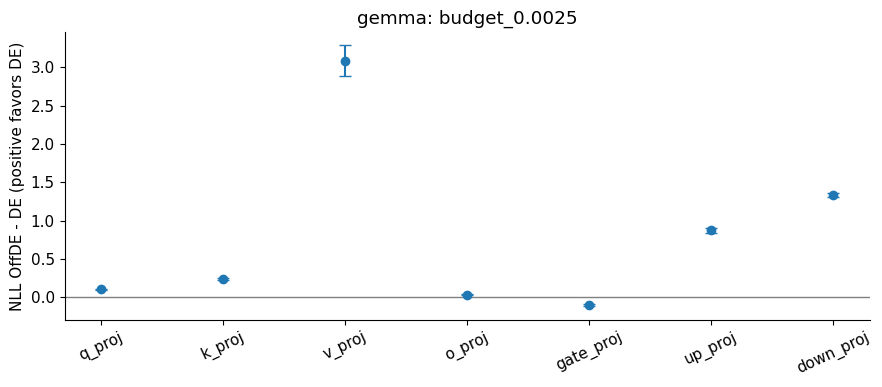

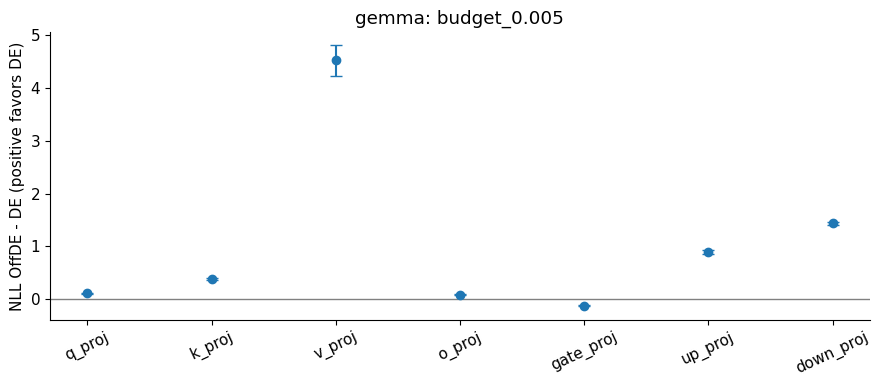

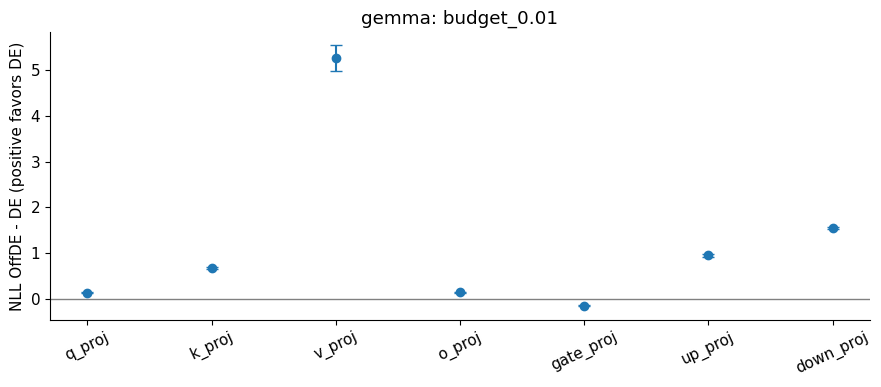

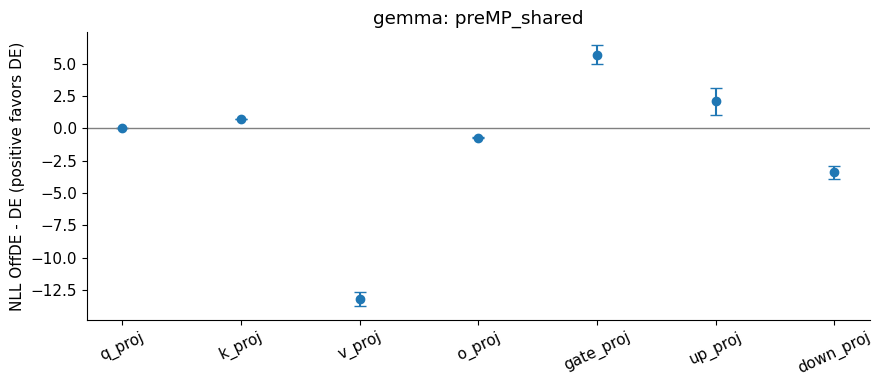

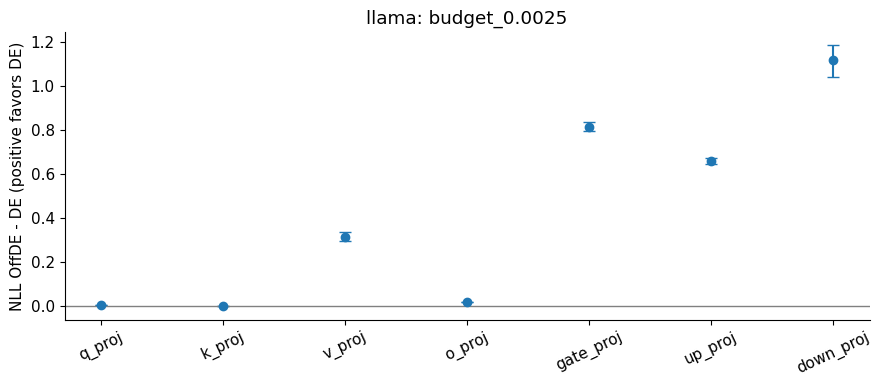

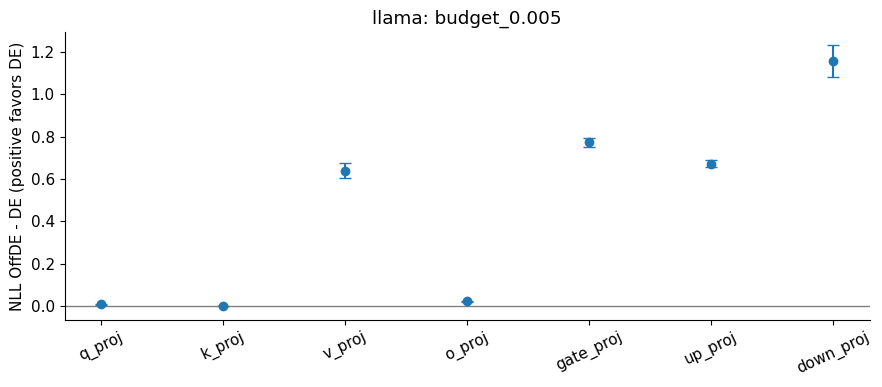

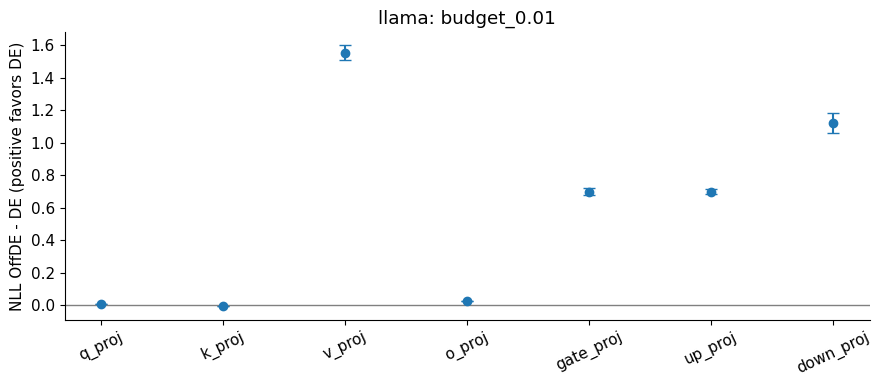

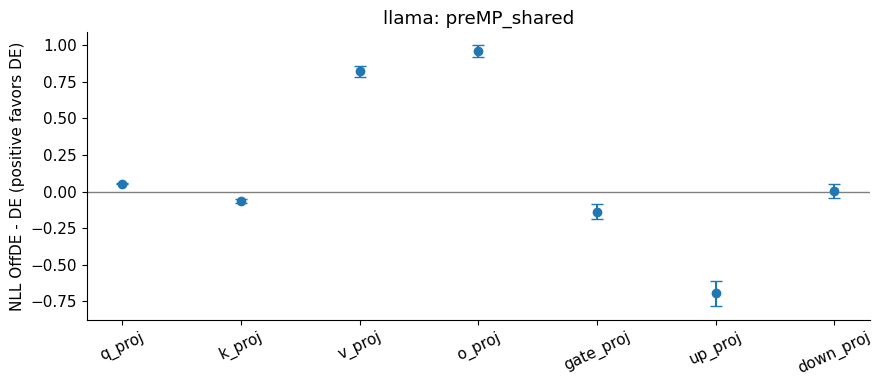

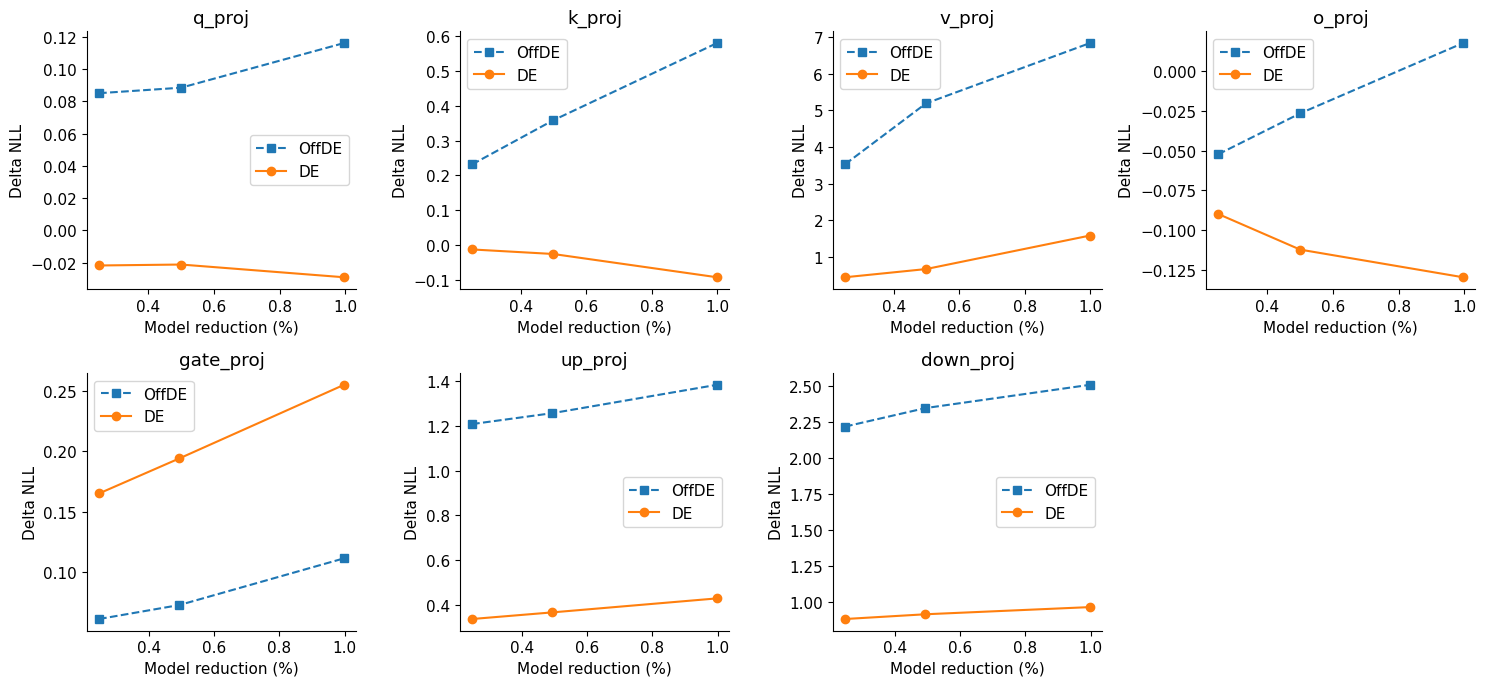

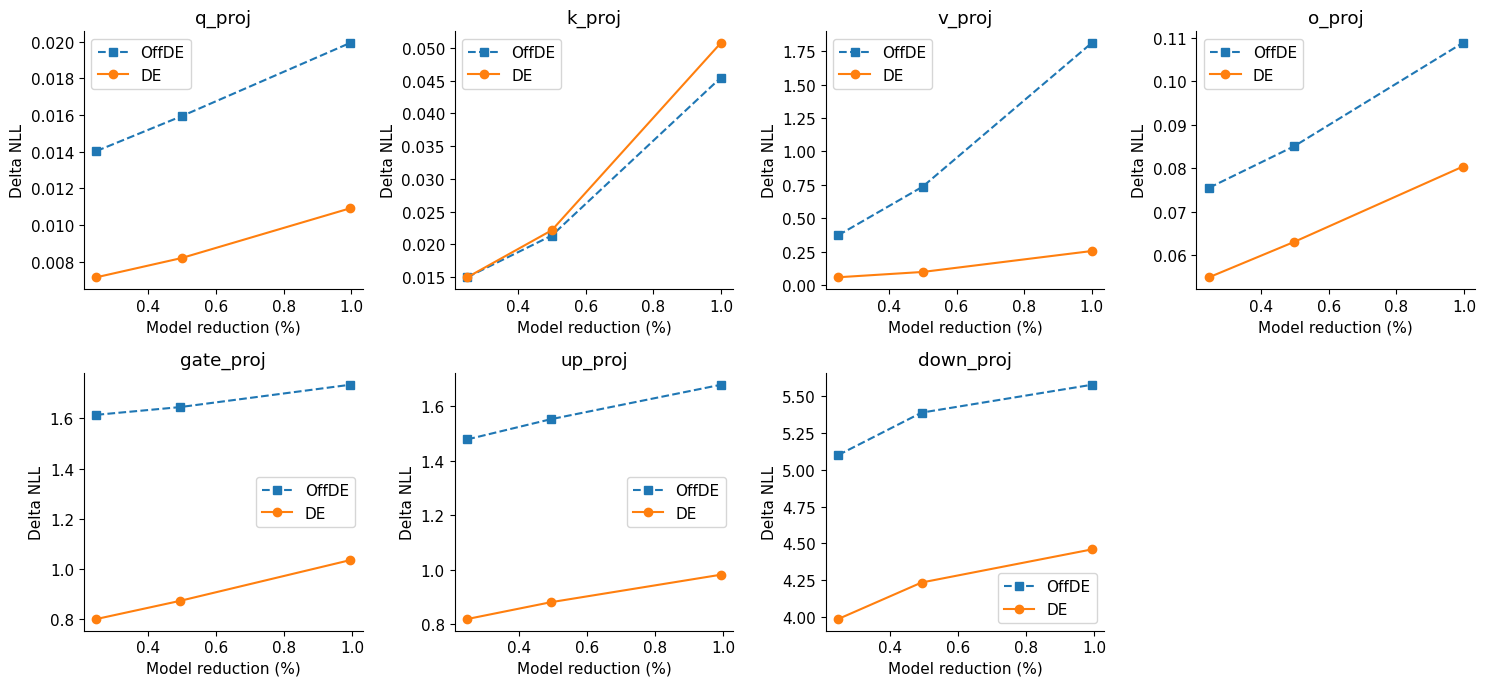

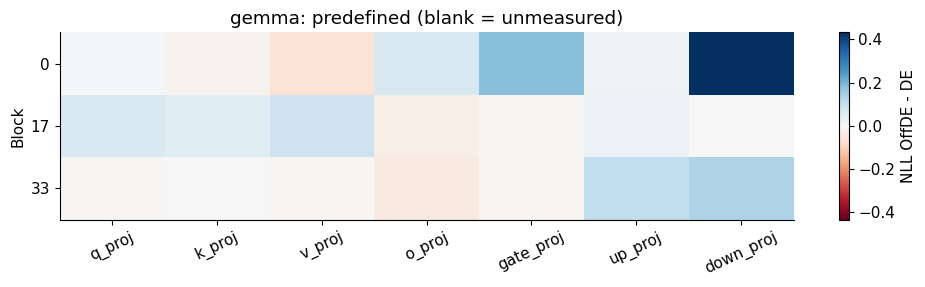

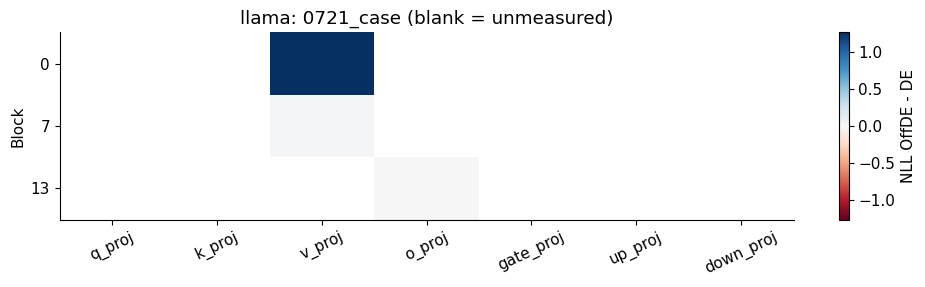

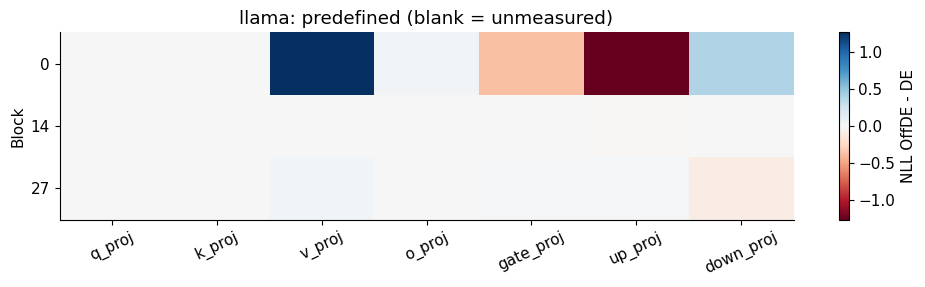

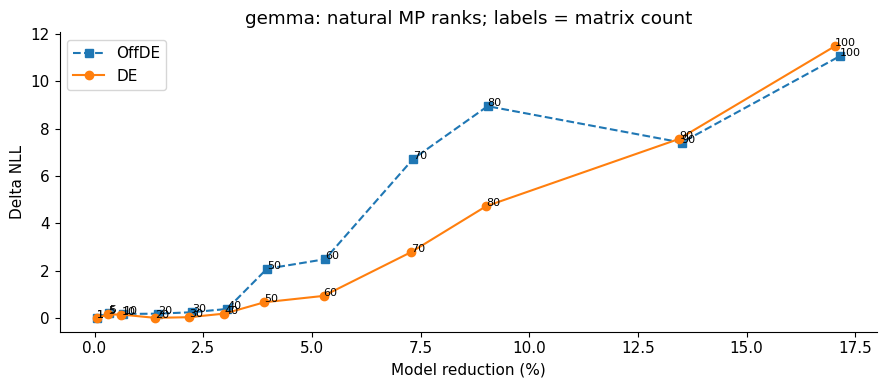

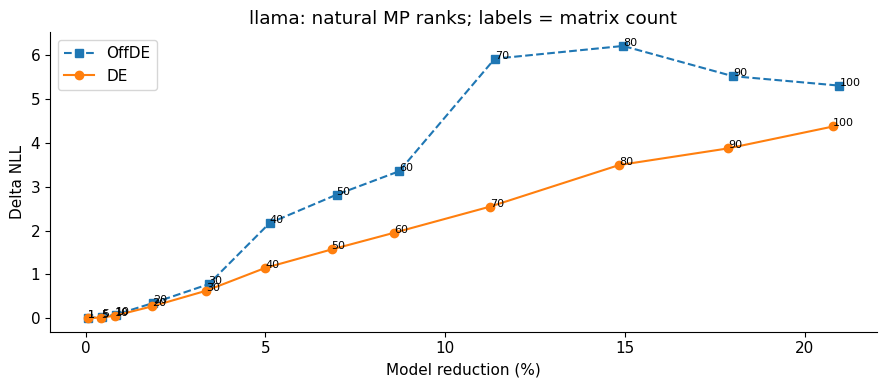

In [9]:
def save_figure(fig,name):
    out=OUTPUT/'figures'; out.mkdir(exist_ok=True)
    fig.tight_layout(); fig.savefig(out/f'{name}.png',dpi=180,bbox_inches='tight'); fig.savefig(out/f'{name}.pdf',bbox_inches='tight')
    plt.show(); plt.close(fig)

def plot_results(results,paired):
    if paired.empty: return
    for (model,variant),g in paired[paired.experiment=='E1'].groupby(['model','variant']):
        g=g.set_index('scope').reindex(MODULES).dropna(subset=['gain'])
        fig,ax=plt.subplots(); x=np.arange(len(g))
        ax.errorbar(x,g.gain,yerr=np.maximum(0,np.vstack([g.gain-g.ci_low,g.ci_high-g.gain])),fmt='o',capsize=4)
        ax.axhline(0,color='gray',lw=1); ax.set_xticks(x,g.index,rotation=25)
        ax.set(title=f'{model}: {variant}',ylabel='NLL OffDE - DE (positive favors DE)')
        save_figure(fig,f'E1_gain_{model}_{variant}')
    for model,g in results[(results.experiment=='E1')&results.variant.str.startswith('budget_')].groupby('model'):
        fig,axes=plt.subplots(2,4,figsize=(15,7)); axes[-1,-1].axis('off')
        for ax,module in zip(axes.flat,MODULES):
            for de,h in g[g.scope==module].groupby('use_de'):
                h=h.sort_values('reduction_model'); ax.plot(h.reduction_model*100,h.delta_nll,'o-' if de else 's--',label='DE' if de else 'OffDE')
            ax.set(title=module,xlabel='Model reduction (%)',ylabel='Delta NLL'); ax.legend()
        save_figure(fig,f'E1_budget_curves_{model}')
    for (model,variant),g in paired[paired.experiment=='E2'].groupby(['model','variant']):
        g=g.copy(); g['block']=g.scope.str.extract(r'layers\.(\d+)\.')[0].astype(int)
        g['module']=g.scope.str.split('.').str[-1]
        table=g.pivot(index='block',columns='module',values='gain').reindex(columns=MODULES)
        fig,ax=plt.subplots(figsize=(10,max(3,.3*len(table))))
        bound=max(float(np.nanmax(np.abs(table.values))),1e-8)
        im=ax.imshow(np.ma.masked_invalid(table.values),aspect='auto',cmap='RdBu',vmin=-bound,vmax=bound)
        ax.set_xticks(range(7),MODULES,rotation=25); ax.set_yticks(range(len(table)),table.index)
        ax.set(title=f'{model}: {variant} (blank = unmeasured)',ylabel='Block')
        fig.colorbar(im,ax=ax,label='NLL OffDE - DE'); save_figure(fig,f'E2_heatmap_{model}_{variant}')
    for model,g in results[results.experiment=='E3'].groupby('model'):
        fig,ax=plt.subplots()
        for de,h in g.groupby('use_de'):
            h=h.sort_values('step'); ax.plot(h.reduction_model*100,h.delta_nll,'o-' if de else 's--',label='DE' if de else 'OffDE')
            for r in h.itertuples(): ax.annotate(str(r.step),(100*r.reduction_model,r.delta_nll),fontsize=8)
        ax.set(xlabel='Model reduction (%)',ylabel='Delta NLL',title=f'{model}: natural MP ranks; labels = matrix count'); ax.legend()
        save_figure(fig,f'E3_tradeoff_{model}')
plot_results(RESULTS,PAIRED)

## 9. 集計の読み方・保存・終了
`gain>0`はDE優位。区間が0を跨ぐ場合はこの評価集合で明確な改善としません。E1の共通予算とpreDE MP rank固定を主比較、E2は位置依存性、E3はパイプラインのトレードオフです。E3で高削減・高PPLだったことだけでは「削減が多いため」と因果的に説明できません。
このノートブックは再構成した密行列で推論するので、削減率は**理論的な低ランク因子の保存量**です。実速度・VRAM削減を示しません。結果がDEに不利な場合も全条件を保存します。
Driveにplan・rank表・結果CSV・token別ではなくblock別損失・図PDF/PNGを保存。W&Bは下の設定がTrueの場合のみ、集計結果を追加します。

In [ ]:
if not PAIRED.empty:
    lines=['# IBIS2026 DE対応比較（自動集計）',f'完了run: {len(RESULTS)}/{len(JOBS)}',
           'G=NLL_OffDE−NLL_DE。正はDE優位。CIは評価ブロック群bootstrap。']
    for (model,exp,variant),g in PAIRED.groupby(['model','experiment','variant']):
        lines.append(f'- {model}/{exp}/{variant}: {len(g)} pairs; G>0={int((g.gain>0).sum())}; CI lower>0={int((g.ci_low>0).sum())}')
    lines.append('未完了条件を含む場合は暫定結果。効果方向の件数は独立標本の検定ではない。')
    (OUTPUT/'analysis_summary.md').write_text('\n'.join(lines))
    print('\n'.join(lines))
    if PUBLISH_WANDB:
        import wandb
        if not os.environ.get('WANDB_API_KEY'): os.environ['WANDB_API_KEY']=getpass.getpass('WANDB_API_KEY: ')
        with wandb.init(entity=WANDB_ENTITY,project=WANDB_PROJECT,name=EXPERIMENT_TAG,config={'config_hash':CONFIG_HASH}) as run:
            run.log({'results':wandb.Table(dataframe=RESULTS),'paired':wandb.Table(dataframe=PAIRED)})
            artifact=wandb.Artifact(EXPERIMENT_TAG,type='evaluation')
            for name in ['plan.csv','results.csv','paired_comparisons.csv','manifest.json','analysis_summary.md']:
                if (OUTPUT/name).exists(): artifact.add_file(str(OUTPUT/name))
            run.log_artifact(artifact)
if AUTO_DISCONNECT and RUN_EXPERIMENTS and len(RESULTS)==len(JOBS) and Path('/content').exists():
    from google.colab import runtime
    runtime.unassign()